# marv-hyena round 2: fixing round 1's experiment design

Round 1 ([RESEARCH_LOG.md](https://github.com/thebnbrkr/marv-hyena/blob/main/RESEARCH_LOG.md)) found two things
that changed the plan:

1. **Block 30 (the last LI block) got all of the direct credit** for the model's predictions. The hypothesis is that
   its output is far larger than every other block's, so the output layer effectively reads only block 30.
2. **Switching off a whole operator type broke the model.** SE, MR and LI families all pushed it to chance-level
   guessing, so those rows measured "broken model", not "what this part does".

Round 2:
- **R2.1** checks the block-30 hypothesis directly (the output size of every block).
- Every ablation now carries a **health check** (is the model still working?).
- Families are ablated **without the bottleneck block**, and also **one layer at a time**.
- The motif search gets a **composition control** and a **per-position importance** map.
- BRCA1 patching is done **at the mutation site only**, on variants with a real effect, plus a small
  **harmful-vs-harmless scoring check** across 40 variants.

**Runtime:** A100 + High-RAM, as before.

## 0. Setup

In [1]:
# GPU check (no torch import yet: the install below may change the torch version)
!nvidia-smi --query-gpu=name,memory.total,compute_cap --format=csv

name, memory.total [MiB], compute_cap
NVIDIA A100-SXM4-80GB, 81920 MiB, 8.0


In [2]:
# OPTIONAL: keep the ~15 GB Evo 2 weights on Google Drive so the next session skips the download.
# This must run BEFORE anything imports huggingface_hub / evo2.
USE_DRIVE = False

import os
if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    os.environ['HF_HOME'] = '/content/drive/MyDrive/hf_cache'
    os.makedirs(os.environ['HF_HOME'], exist_ok=True)
print('HF_HOME =', os.environ.get('HF_HOME', '(default ~/.cache/huggingface)'))

HF_HOME = (default ~/.cache/huggingface)


In [3]:
# Install Evo 2 + marv-hyena (~2-5 min). NO flash-attn: pip usually finds no prebuilt wheel for Colab's torch
# and compiles for hours. marv-hyena instead runs Evo 2's attention through PyTorch's built-in fused kernel
# (scaled_dot_product_attention), which is also fast on an A100 -- see marv_hyena/noflash.py.
# Colab runs Python 3.13, but every current evo2 release declares Python < 3.13, so a plain `pip install evo2`
# silently falls back to the old, incompatible 0.3.0. evo2 is pure Python, so force the current release.
# Colab also ships an empty `transformer-engine` package whose import crashes evo2; remove it (7B needs no TE).
!pip uninstall -y -q transformer-engine transformer_engine
!pip install -q --ignore-requires-python evo2==0.6.0
!rm -rf marv-hyena && git clone -q https://github.com/thebnbrkr/marv-hyena.git
!pip install -q -r marv-hyena/requirements.txt openpyxl

import sys
sys.path.insert(0, '/content/marv-hyena')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.9/42.9 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.4/6.4 MB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 124.7 MB/s eta 0:00:00


In [4]:
# Must run before anything imports evo2/vortex: lets Vortex import without flash-attn and turns flash attention off.
from marv_hyena import noflash
noflash.prepare()

import torch, vortex, evo2
from importlib.metadata import version
print('evo2', version('evo2'), '| vtx', version('vtx'))
assert version('evo2') >= '0.6.0', 'old evo2 installed: Runtime -> Disconnect and delete runtime, then rerun from the top'
print('torch', torch.__version__, '| cuda', torch.version.cuda, '| flash-attn package installed:', noflash.flash_attn_available())
print('GPU', torch.cuda.get_device_name(0), 'capability', torch.cuda.get_device_capability(0))
assert torch.cuda.get_device_capability(0)[0] >= 8, 'needs an Ampere+ GPU with bf16 (A100 / L4 / H100)'

evo2 0.6.0 | vtx 1.1.0
torch 2.11.0+cu128 | cuda 12.8 | flash-attn package installed: False
GPU NVIDIA A100-SXM4-80GB capability (8, 0)


In [5]:
# marv-hyena's own tests (a tiny CPU model that mirrors Vortex). Should say "29 passed".
!cd marv-hyena && python -m pytest -q

.............................                                            [100%]
29 passed in 3.69s


In [6]:
# Data: the annotated E. coli K-12 genome from the evo2 repo
import os, urllib.request
os.makedirs('data', exist_ok=True)
EVO2_RAW = 'https://raw.githubusercontent.com/ArcInstitute/evo2/main/notebooks'
GENOME = 'data/NC_000913.gb'
if not os.path.exists(GENOME):
    urllib.request.urlretrieve(f'{EVO2_RAW}/sparse_autoencoder/NC_000913.gb', GENOME)

import marv_hyena as mh
from marv_hyena.probes import load_sequence
genome = load_sequence(GENOME)
print(f'E. coli genome: {len(genome):,} letters')

E. coli genome: 4,641,652 letters


In [7]:
# Load Evo 2 7B (downloads ~15 GB the first time)
import time
MODEL_NAME = 'evo2_7b'
t0 = time.time()
hm = mh.HyenaModel.load(MODEL_NAME)
print(f'loaded in {time.time()-t0:.0f}s')
print(hm.describe())
RESULTS = {}

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Found complete file in repo: evo2_7b.pt


/usr/local/lib/python3.13/dist-packages/evo2/models.py:294: UserWarning: Transformer Engine not installed. Falling back to bf16 projections (use_fp8_input_projections=False). 
  warnings.warn(


  0%|          | 0/32 [00:00<?, ?it/s]

 12%|█▎        | 4/32 [00:00<00:01, 23.40it/s]

100%|██████████| 32/32 [00:00<00:00, 116.63it/s]


Extra keys in state_dict: {'blocks.9.mixer.mixer.filter.t', 'blocks.31.mixer.attn._extra_state', 'blocks.13.projections._extra_state', 'blocks.29.projections._extra_state', 'blocks.17.mixer.attn._extra_state', 'blocks.0.projections._extra_state', 'blocks.20.mixer.mixer.filter.t', 'blocks.31.mixer.dense._extra_state', 'blocks.7.projections._extra_state', 'blocks.22.projections._extra_state', 'blocks.6.mixer.mixer.filter.t', 'blocks.21.projections._extra_state', 'unembed.weight', 'blocks.18.projections._extra_state', 'blocks.15.projections._extra_state', 'blocks.16.mixer.mixer.filter.t', 'blocks.2.mixer.mixer.filter.t', 'blocks.11.projections._extra_state', 'blocks.1.projections._extra_state', 'blocks.24.mixer.attn._extra_state', 'blocks.30.projections._extra_state', 'blocks.10.mixer.dense._extra_state', 'blocks.5.projections._extra_state', 'blocks.27.projections._extra_state', 'blocks.19.projections._extra_state', 'blocks.4.projections._extra_state', 'blocks.12.projections._extra_state'

In [8]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, json
from marv_hyena import diagnostics, motifs
from marv_hyena.checks import run_smoke_checks
from marv_hyena.experiments import make_conditions, copy_test, codon_test, context_test, periodicity, summarize_copy

seq = genome[100_000:104_096]
assert run_smoke_checks(hm, seq), 'smoke checks failed: stop here'
HEALTH_SEQ = genome[300_000:304_096]          # ordinary genome used to check the model still works
print('baseline health:', diagnostics.health(hm, HEALTH_SEQ))
RESULTS = {}

[PASS] embed + sum(writes) == final residual  rel_err=8.21e-06
[PASS] trace rows sum to real logit diff  sum=+8.541 actual=+8.505
[PASS] distance bands reconstruct block 14 (se)  rel_err=3.98e-03
[PASS] distance bands reconstruct block 15 (mr)  rel_err=3.41e-03
[PASS] distance bands reconstruct block 16 (li)  rel_err=2.66e-03
[PASS] block 0 receptive field small enough to enumerate  measured 9 letters
[PASS] hooks removed after intervention  
[PASS] mean-ablating LI mixers changes the output  

8/8 checks passed
baseline health: {'health_acc': 0.6959707140922546, 'health_lp': -0.6843298673629761, 'broken': False}


## R2.1 Is block 30 an output bottleneck?

Measure the size (L2 norm) of every block's residual write, and what share of the final residual it makes up, at
positions in three different stretches of genome. If block 30's mixer is most of the final residual everywhere, the
hypothesis holds.

--- genome[100000:+4096]
component                  norm  share of final
L30 li mixer       708615798784.0         100.0%
L29 mr mlp            5751513.5           0.0%
L29 mr mixer           222839.3           0.0%
L28 se mlp               9235.0           0.0%
L28 se mixer               28.1           0.0%
L27 li mlp                 17.3           0.0%
--- genome[1000000:+4096]
component                  norm  share of final
L30 li mixer       4415427706880.0         100.0%
L29 mr mlp            9043202.0           0.0%
L29 mr mixer           254269.7           0.0%
L28 se mlp               4934.3           0.0%
L28 se mixer               29.8           0.0%
L27 li mlp                 18.4           0.0%
--- genome[3000000:+4096]
component                  norm  share of final
L30 li mixer       1304444403712.0         100.0%
L29 mr mlp            7688624.0           0.0%
L29 mr mixer           236583.4           0.0%
L28 se mlp               6514.0           0.0%
L28 se mixer       

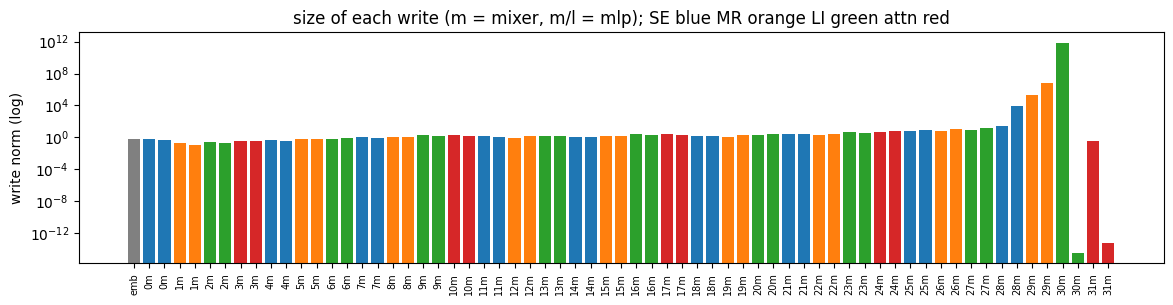

In [9]:
norm_rows = []
for start in (100_000, 1_000_000, 3_000_000):
    s = genome[start:start + 4096]
    rows = diagnostics.write_norms(hm, s, [1000, 2000, 4095])
    print(f'--- genome[{start}:+4096]')
    diagnostics.show_write_norms(rows, k=6)
    norm_rows.append(rows)

BOTTLENECK = diagnostics.find_bottlenecks(hm, seq, [1000, 2000, 4095])
print('\nbottleneck blocks (write >= 50% of final residual norm):', BOTTLENECK)
RESULTS['write_norms'] = [[{'block': r.block, 'kind': r.kind, 'part': r.part, 'norm': r.norm, 'share': r.share}
                           for r in rows] for rows in norm_rows]
RESULTS['bottleneck'] = BOTTLENECK

rows = norm_rows[0]
labels = ['emb'] + [f'{r.block}{r.part[0]}' for r in rows[1:]]
cols = ['grey'] + [{'se': 'C0', 'mr': 'C1', 'li': 'C2', 'attn': 'C3'}[r.kind] for r in rows[1:]]
plt.figure(figsize=(14, 3))
plt.bar(range(len(rows)), [r.norm for r in rows], color=cols)
plt.yscale('log'); plt.xticks(range(len(rows)), labels, rotation=90, fontsize=7)
plt.ylabel('write norm (log)'); plt.title('size of each write (m = mixer, m/l = mlp); SE blue MR orange LI green attn red')
plt.show()

## R2.2 One layer at a time: what breaks?

For each of the 32 blocks, switch off **only that block's mixer** (replaced with its average output) and measure:
- **health**: next-letter accuracy on ordinary genome (is the model still working?);
- **codon rhythm**: accuracy at codon positions 1–2 minus position 3;
- **copying**: second-copy accuracy with gaps of 1,000 and 10,000 letters.

This is the table that tells us which single layers are load-bearing for which job.

In [10]:
track = mh.genbank_track(GENOME, 200_000, 208_192)
single = make_conditions(hm, families=(), single_blocks=range(hm.n_blocks))
codon_rows = codon_test(hm, track, conditions=single)
per = periodicity(codon_rows)
copy_rows = copy_test(hm, genome, gaps=(1000, 10000), insert_len=200, seeds=1, conditions=single, verbose=False)

layer_table = []
for name in single:
    h = next(r for r in codon_rows if r['condition'] == name)
    c = {g: np.mean([r['second_acc'] for r in copy_rows if r['condition'] == name and r['gap'] == g]) for g in (1000, 10000)}
    layer_table.append({'condition': name, 'health_acc': h['health_acc'], 'broken': h['broken'],
                        'codon_rhythm': per[name], 'copy@1k': c[1000], 'copy@10k': c[10000]})
df_layers = pd.DataFrame(layer_table).set_index('condition')
RESULTS['single_layer'] = layer_table
df_layers.round(3)

,health_acc,broken,codon_rhythm,copy@1k,copy@10k
condition,,,,,
none,0.859,False,0.251,1.000,0.994
-L0(se),0.288,True,-0.042,0.239,0.256
-L1(mr),0.367,True,-0.077,1.000,1.000
-L2(li),0.845,False,0.255,0.972,0.822
-L3(attn),0.856,False,0.254,0.939,0.633
-L4(se),0.799,False,0.262,0.989,0.978
-L5(mr),0.700,False,0.191,1.000,1.000
-L6(li),0.832,False,0.261,1.000,0.994
-L7(se),0.806,False,0.243,1.000,0.994


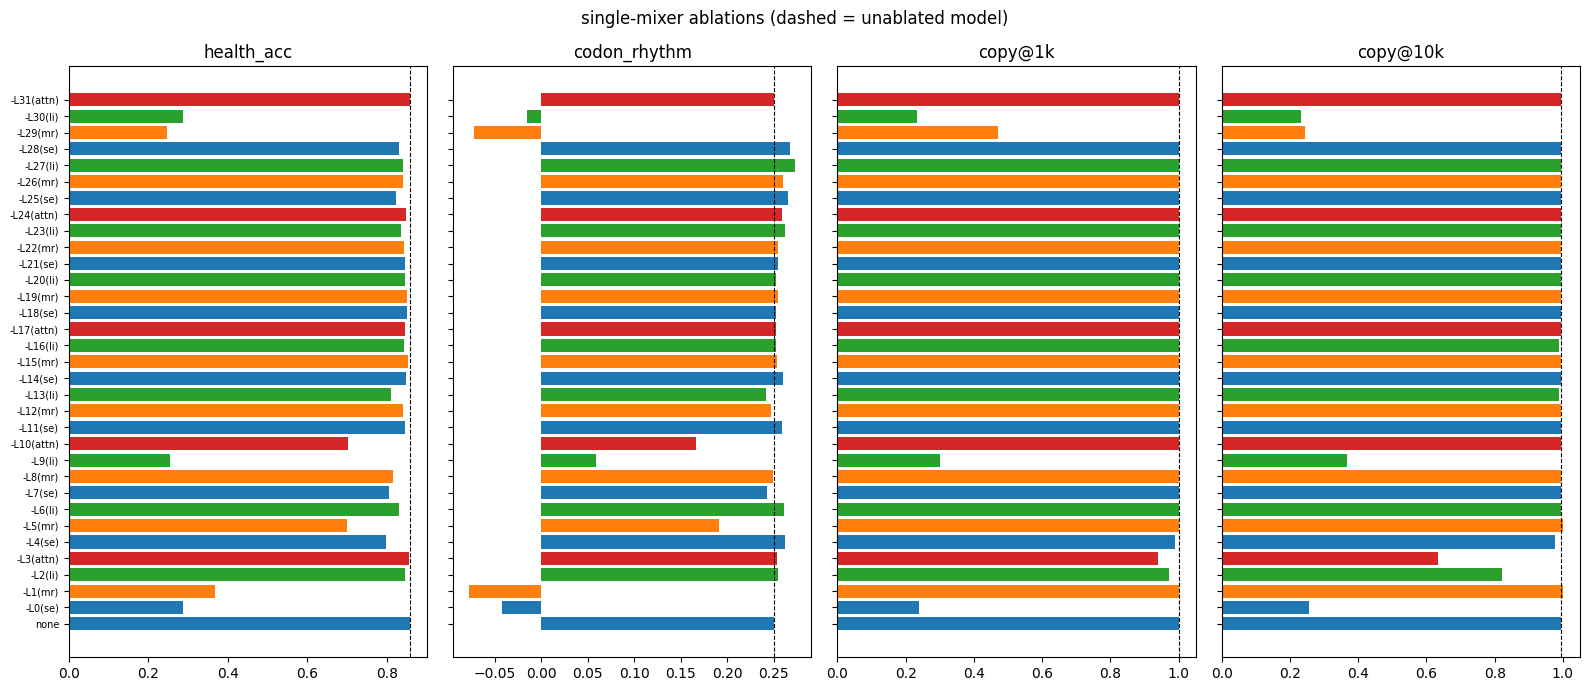

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(16, 7), sharey=True)
for ax, col in zip(axes, ['health_acc', 'codon_rhythm', 'copy@1k', 'copy@10k']):
    v = df_layers[col].values
    ax.barh(range(len(v)), v, color=['C3' if '(attn)' in n else 'C2' if '(li)' in n else 'C1' if '(mr)' in n else 'C0'
                                     for n in df_layers.index])
    ax.axvline(df_layers.loc['none', col], color='k', ls='--', lw=0.8)
    ax.set_title(col); ax.invert_yaxis()
axes[0].set_yticks(range(len(df_layers))); axes[0].set_yticklabels(df_layers.index, fontsize=7)
plt.suptitle('single-mixer ablations (dashed = unablated model)'); plt.tight_layout(); plt.show()

## R2.3 Whole families again, this time without the bottleneck

The same family ablations as round 1, but block 30 (or whatever R2.1 found) is kept switched on. Rows where
`broken` is True are still uninterpretable. Report them, but don't read meaning into them.

In [12]:
fam = make_conditions(hm, exclude_blocks=BOTTLENECK)
print('conditions:', list(fam))

copy2 = copy_test(hm, genome, gaps=(100, 1000, 10000), insert_len=200, seeds=2, conditions=fam,
                  health_seq=HEALTH_SEQ, verbose=False)
gaps, conds, a2, a1 = summarize_copy(copy2)
health_by = {r['condition']: (r['health_acc'], r['broken']) for r in copy2}
print(f"{'condition':<22} {'health':>7} {'broken':>7} " + ' '.join(f'copy@{g:>6}' for g in gaps))
for j, c in enumerate(conds):
    print(f'{c:<22} {health_by[c][0]:>7.3f} {str(health_by[c][1]):>7} ' + ' '.join(f'{a2[i, j]:>11.3f}' for i in range(len(gaps))))
RESULTS['copy_families'] = copy2

conditions: ['none', '-se', '-mr', '-li (keep L30)', '-attn']
condition               health  broken copy@   100 copy@  1000 copy@ 10000
none                     0.696   False       1.000       1.000       0.997
-se                      0.275    True       0.236       0.239       0.158
-mr                      0.279    True       0.344       0.481       0.408
-li (keep L30)           0.214    True       0.269       0.269       0.247
-attn                    0.571   False       0.253       0.244       0.247


In [13]:
codon2 = codon_test(hm, track, conditions=fam)
RESULTS['codon_families'] = codon2
t = pd.DataFrame(codon2).pivot(index='condition', columns='region', values='acc')
t['rhythm'] = pd.Series(periodicity(codon2))
t['health_acc'] = pd.DataFrame(codon2).groupby('condition')['health_acc'].first()
t['broken'] = pd.DataFrame(codon2).groupby('condition')['broken'].first()
t.round(3)

region,codon_pos1,codon_pos2,codon_pos3,intergenic,rhythm,health_acc,broken
condition,,,,,,,
-attn,0.701,0.759,0.585,0.330,0.145,0.670,False
-li (keep L30),0.239,0.300,0.245,0.288,0.025,0.262,True
-mr,0.233,0.218,0.298,0.195,-0.072,0.248,True
-se,0.003,0.002,0.000,0.000,0.002,0.001,True
none,0.936,0.964,0.700,0.618,0.251,0.859,False


In [14]:
# P2 on 5 genes instead of 1: does far-away DNA help, and which family carries it?
from Bio import SeqIO
rec = next(SeqIO.parse(GENOME, 'genbank'))
UP = 50_000
cands = [f for f in rec.features if f.type == 'CDS' and f.location.strand == 1
         and int(f.location.start) > UP + 10_000 and len(f.location) > 1200]
genes = [cands[i] for i in np.linspace(0, len(cands) - 1, 5).astype(int)]   # 5 genes spread across the genome
ctx_rows = []
for f in genes:
    s = int(f.location.start)
    rows = context_test(hm, genome[s - UP: s + 1000], target=(UP, UP + 1000), short=500, conditions=fam)
    for r in rows:
        r['gene'] = f.qualifiers.get('gene', ['?'])[0]
    ctx_rows += rows
    print('done', rows[0]['gene'])
RESULTS['context_families'] = ctx_rows
dfc = pd.DataFrame(ctx_rows)
dfc.pivot(index='condition', columns='gene', values='context_benefit').round(4)

done ilvI
done uup
done yehQ
done gspE
done creD


gene,creD,gspE,ilvI,uup,yehQ
condition,,,,,
-attn,-0.0009,-0.0020,-0.0027,-0.0006,-0.0006
-li (keep L30),-0.0182,0.0514,-0.0131,0.0181,-0.0080
-mr,0.0007,0.0009,0.0009,0.0003,0.0004
-se,0.0277,0.3649,-0.1005,0.1629,0.0575
none,0.0163,0.0236,0.0167,0.0078,0.0158


## R2.4 First-layer motifs, with controls

Block 0 sees the last 9 letters. We run all 262,144 possible 9-letter inputs through it, then:
- **per-position importance**: for each channel, how much each of the 9 positions affects its output. This is exact,
  from the complete enumeration. It tests the round-1 impression that channels mostly care about the last 5–6 letters.
- **motif counts with a composition control**: a channel only counts as, say, a "TAA channel" if TAA appears in its
  top inputs ≥ 3× more often than chance for a channel with the same A/C/G/T mix. This stops AT-rich channels from
  being counted as TAA channels.

mean importance by position (0 = 8 letters back, 8 = the current letter): [0.03  0.035 0.045 0.045 0.075 0.118 0.142 0.125 0.204]
channels with >= 80% of importance in the last 6 positions: 64.0%
channels with >= 50% in the current letter alone: 18.1%


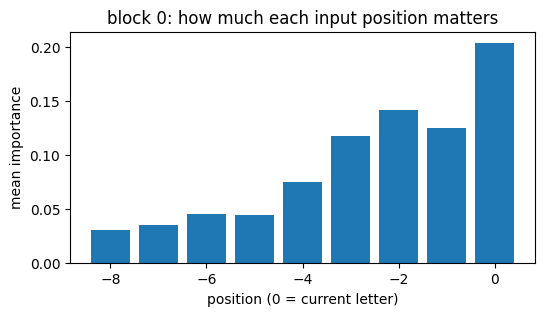

,motif,raw_channels,controlled_channels,examples
0,start ATG,46,46,"[263, 2512, 385, 3575, 3374]"
1,stop TAA,145,65,"[3590, 2513, 2902, 483, 1932]"
2,stop TAG,50,50,"[1523, 1339, 3629, 3574, 1083]"
3,stop TGA,41,41,"[3998, 3248, 3569, 2464, 3027]"
4,Shine-Dalgarno,1,1,[2437]
5,control CCC,264,8,"[51, 94, 431, 2085, 468]"
6,control GCG,95,53,"[2036, 1264, 625, 1733, 1009]"


In [15]:
md_ = motifs.enumerate_block0(hm)
imp = md_.position_importance                     # (9, 4096), columns sum to 1
prof = imp.mean(1)
late = imp[-6:].sum(0)                            # share of each channel's importance in the last 6 positions
print('mean importance by position (0 = 8 letters back, 8 = the current letter):', np.round(prof, 3))
print(f'channels with >= 80% of importance in the last 6 positions: {(late >= 0.8).mean():.1%}')
print(f'channels with >= 50% in the current letter alone: {(imp[-1] >= 0.5).mean():.1%}')
RESULTS['motif_position_profile'] = prof.tolist()

plt.figure(figsize=(6, 3))
plt.bar(range(-8, 1), prof); plt.xlabel('position (0 = current letter)'); plt.ylabel('mean importance')
plt.title('block 0: how much each input position matters'); plt.show()

motif_summary = []
for name, m in [('start ATG', 'ATG'), ('stop TAA', 'TAA'), ('stop TAG', 'TAG'), ('stop TGA', 'TGA'),
                ('Shine-Dalgarno', 'AGGAG'), ('control CCC', 'CCC'), ('control GCG', 'GCG')]:
    raw, ctrl = motifs.motif_channels(md_, m)
    motif_summary.append({'motif': name, 'raw_channels': len(raw), 'controlled_channels': len(ctrl),
                          'examples': [h.channel for h in sorted(ctrl, key=lambda h: -h.enrichment)[:5]]})
RESULTS['motif_counts'] = motif_summary
pd.DataFrame(motif_summary)

In [16]:
# Look at the best controlled channel for each real motif: its top inputs and letter preferences per position
for row in motif_summary[:5]:
    if not row['examples']:
        print(f"{row['motif']}: no channel passes the control"); continue
    c = row['examples'][0]
    pwm = md_.pwm(c)
    print(f"\n{row['motif']}: channel {c}; top inputs {md_.top_kmers[c][:5]}")
    print('pos  ' + '  '.join(f'{p:>2}' for p in range(-8, 1)))
    for j, b in enumerate('ACGT'):
        print(f'  {b}  ' + '  '.join(f'{pwm[i, j]:.1f}'[1:] if pwm[i, j] < 1 else '1.' for i in range(9)))
    print('importance ' + ' '.join(f'{x:.2f}' for x in md_.position_importance[:, c]))


start ATG: channel 263; top inputs ['ACATCATGC', 'GCATCATGC', 'CCATCATGC', 'ACGTCATGC', 'GCGTCATGC']
pos  -8  -7  -6  -5  -4  -3  -2  -1   0
  A  .4  .2  .3  .3  .0  1.  .0  .0  .0
  C  .2  .4  .2  .1  .0  .0  .0  .0  1.
  G  .1  .2  .2  .2  .0  .0  .0  1.  .0
  T  .3  .1  .2  .4  .0  .0  1.  .0  .0
importance 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00

stop TAA: channel 3590; top inputs ['ACCCTTAAG', 'ACCGTTAAC', 'ACCGTTAAG', 'ACGCTTAAG', 'ACGGTTAAC']
pos  -8  -7  -6  -5  -4  -3  -2  -1   0
  A  .3  .0  .0  .0  .3  .0  1.  1.  .0
  C  .3  .5  .5  .4  .0  .0  .0  .0  .5
  G  .3  .5  .5  .6  .0  .0  .0  .0  .6
  T  .2  .0  .0  .0  .7  1.  .0  .0  .0
importance 0.00 0.00 0.00 0.01 0.00 0.10 0.85 0.04 0.01

stop TAG: channel 1523; top inputs ['TAGAAGTCC', 'TAGTTAGCC', 'TAGAAGCCC', 'TAGTTACCC', 'TAGTGACCC']
pos  -8  -7  -6  -5  -4  -3  -2  -1   0
  A  .0  1.  .0  .2  .2  .3  .2  .0  .0
  C  .0  .0  .0  .2  .2  .2  .3  1.  1.
  G  .0  .0  1.  .1  .2  .2  .2  .0  .0
  T  1.  .0  .0  .5  .

## R2.5 BRCA1: does Evo 2 separate harmful from harmless, and where does the mutation's signal enter?

1. Score 20 loss-of-function (LOF) and 20 functional (FUNC) variants, and check whether LOF variants score lower
   (AUROC: 0.5 = no better than chance, 1.0 = perfect separation).
2. For the 3 LOF variants with the largest effect on the letters that follow, patch each component **at the mutation
   site only** (the round-1 all-position patching mostly measured the block-30 bottleneck).

In [17]:
import gzip, os, urllib.request
from sklearn.metrics import roc_auc_score
for f in ['GRCh37.p13_chr17.fna.gz', '41586_2018_461_MOESM3_ESM.xlsx']:
    if not os.path.exists(f'data/{f}'):
        urllib.request.urlretrieve(f'{EVO2_RAW}/brca1/{f}', f'data/{f}')
with gzip.open('data/GRCh37.p13_chr17.fna.gz', 'rt') as h:
    chr17 = str(next(SeqIO.parse(h, 'fasta')).seq).upper()
brca1 = pd.read_excel('data/41586_2018_461_MOESM3_ESM.xlsx', header=2)[
    ['chromosome', 'position (hg19)', 'reference', 'alt', 'function.score.mean', 'func.class']]
sample = pd.concat([brca1[brca1['func.class'] == 'LOF'].sample(20, random_state=0),
                    brca1[brca1['func.class'] == 'FUNC'].sample(20, random_state=0)])
var_rows = []
for _, row in sample.iterrows():
    v = mh.make_variant(chr17, int(row['position (hg19)']) - 1, row['reference'], row['alt'], window=8192)
    var_rows.append({'pos': int(row['position (hg19)']), 'ref': row['reference'], 'alt': row['alt'],
                     'class': row['func.class'], 'lab_score': float(row['function.score.mean']),
                     'delta_logp': mh.delta_logp(hm, v), 'downstream_effect': mh.variants.downstream_effect(hm, v)})
dv = pd.DataFrame(var_rows)
auc = roc_auc_score((dv['class'] == 'LOF').astype(int), -dv['delta_logp'])
print(f'AUROC (LOF vs FUNC, lower delta_logp = more harmful): {auc:.3f}   (n=40; the Evo 2 paper uses thousands)')
print(dv.groupby('class')[['delta_logp', 'downstream_effect']].mean())
RESULTS['brca1_scores'] = var_rows
RESULTS['brca1_auroc_n40'] = auc

AUROC (LOF vs FUNC, lower delta_logp = more harmful): 0.880   (n=40; the Evo 2 paper uses thousands)
       delta_logp  downstream_effect
class                               
FUNC    -0.001001          -4.412528
LOF     -0.004584         -22.334751


In [18]:
top = dv[dv['class'] == 'LOF'].reindex(dv[dv['class'] == 'LOF']['downstream_effect'].abs().sort_values(ascending=False).index).head(3)
site_rows = []
for _, row in top.iterrows():
    if abs(row['downstream_effect']) < 1.0:
        print(f"skip {row['pos']}: effect {row['downstream_effect']:+.2f} too small to split"); continue
    v = mh.make_variant(chr17, row['pos'] - 1, row['ref'], row['alt'], window=8192)
    sweep = mh.explain_variant(hm, v, span=200, at='variant')
    print(f"\n===== chr17:{row['pos']} {row['ref']}>{row['alt']}  downstream effect {row['downstream_effect']:+.2f}")
    sweep.show(k=10)
    for r in sweep.results:
        name = r.component if isinstance(r.component, str) else f'L{r.component[0]} {r.kind} {r.component[1]}'
        site_rows.append({'variant': row['pos'], 'component': name, 'fraction': r.fraction})
RESULTS['brca1_site_patching'] = site_rows
if site_rows:
    ds = pd.DataFrame(site_rows).pivot(index='component', columns='variant', values='fraction')
    display(ds.loc[[i for i in ds.index if i.startswith('all')]].round(3))


===== chr17:41256881 T>C  downstream effect -52.37
target run=-209.440  source run=-261.809  difference=-52.369
  all mlps               restores   +4.2%   (metric -211.640)
  all se mixers          restores   -3.3%   (metric -207.717)
  L0  se   mlp           restores   +2.2%   (metric -210.596)
  L3  attn mixer         restores   +1.4%   (metric -210.194)
  L3  attn mlp           restores   +1.4%   (metric -210.178)
  L0  se   mixer         restores   -1.3%   (metric -208.763)
  all mr mixers          restores   -1.3%   (metric -208.780)
  L1  mr   mixer         restores   -0.9%   (metric -208.965)
  L4  se   mixer         restores   -0.8%   (metric -209.030)
  all attn mixers        restores   +0.7%   (metric -209.832)

===== chr17:41256880 C>G  downstream effect -50.20
target run=-209.653  source run=-259.851  difference=-50.198
  all mlps               restores   +2.2%   (metric -210.749)
  all li mixers          restores   +1.5%   (metric -210.425)
  L1  mr   mlp           resto

variant,41219643,41256880,41256881
component,,,
all attn mixers,-0.013,0.008,0.007
all li mixers,0.009,0.015,-0.006
all mlps,0.653,0.022,0.042
all mr mixers,0.006,0.003,-0.013
all se mixers,0.635,-0.005,-0.033


## Save

Download `results_round2.json` (or it goes to Drive if you mounted it), then send it back together with the executed
notebook.

In [19]:
out = '/content/drive/MyDrive/marv_hyena_results_round2.json' if USE_DRIVE else 'results_round2.json'
with open(out, 'w') as f:
    json.dump(RESULTS, f, indent=1, default=float)
print('wrote', out)

wrote results_round2.json
